# Running Walrus outside of train.py

Hello! In this demo, we'll walk you how to use the Walrus foundation model outside of our provided training code. While the training code has many features 
and options, this can also make it a bit hard to catch the essentials. That is why this notebook exists. We'll walk you through how to use
Walrus, primarily in inference here, both with Well formatted data and if you have data you can't force into the Well's format to use our included data utilities. 

## Part 1: Using Walrus with Well-style datasets

Prereqs:
- Since this is using Well-style datasets, this section assumes you have Well-structured data, likely downloaded into a folder structure matching the one you'd get from downloading [The Well](https://github.com/PolymathicAI/the_well). 
- While this example only covers inference, this is using a 1.3B parameter model, so it is necessary to have either enough RAM if using CPU (slow) or VRAM if using GPU to handle a model of this size.

The Walrus codebase is designed with Well-style datasets in mind. While it is not necessary to use these for Walrus,
we're going to cover this option first since it's going to be a bit more straightforward.

We're also going to take advantage of [Hydra](https://hydra.cc) to translate between OmegaConf configs and datasets and the pretrained Walrus model.
Hydra is useful for hierarchical instantiation. It lets us break torch modules into individual component types and define models as a hierarchy 
of modular components that can be swapped out completely for other components. 

As a first step, we're just going to download the data. We'll just use wget to pull it from huggingface.

%matplotlib inline

In [23]:
import os

checkpoint_base_path = "./checkpoints/"
config_base_path = "./configs/"
os.makedirs(checkpoint_base_path, exist_ok=True)
os.makedirs(config_base_path, exist_ok=True)

# And we'll download the weights from huggingface
!wget  https://huggingface.co/polymathic-ai/walrus/resolve/main/extended_config.yaml \
    -O {config_base_path}/extended_config.yaml
!wget  https://huggingface.co/polymathic-ai/walrus/resolve/main/walrus.pt \
    -O {checkpoint_base_path}/walrus.pt

--2026-07-29 03:20:29--  https://huggingface.co/polymathic-ai/walrus/resolve/main/extended_config.yaml
Resolving huggingface.co (huggingface.co)... 3.168.73.111, 3.168.73.129, 3.168.73.106, ...
Connecting to huggingface.co (huggingface.co)|3.168.73.111|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/models/polymathic-ai/walrus/f8fd578e7d8a15d2e510d32d5952b9eddc37548c/extended_config.yaml?%2Fpolymathic-ai%2Fwalrus%2Fresolve%2Fmain%2Fextended_config.yaml=&etag=%223eb6c57e518c935eba9ade2e0b7a3b3381f491b6%22 [following]
--2026-07-29 03:20:29--  https://huggingface.co/api/resolve-cache/models/polymathic-ai/walrus/f8fd578e7d8a15d2e510d32d5952b9eddc37548c/extended_config.yaml?%2Fpolymathic-ai%2Fwalrus%2Fresolve%2Fmain%2Fextended_config.yaml=&etag=%223eb6c57e518c935eba9ade2e0b7a3b3381f491b6%22
Reusing existing connection to huggingface.co:443.
HTTP request sent, awaiting response... 200 OK
Length: 8037 (7.8K) [text/plain]
Saving to

In [24]:
from pathlib import Path
import sys

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "walrus").is_dir():
        print("Possible repository root:", parent)

sys.path.insert(
    0,
    "/mnt/home/pmukhopadhyay/projects/walrus_final/walrus",
)

Possible repository root: /mnt/home/pmukhopadhyay/projects/walrus_final/walrus
Possible repository root: /mnt/home/pmukhopadhyay/projects/walrus_final


In [25]:
import torch
from walrus.data.multidataset import MixedWellDataset
from walrus.data.inflated_dataset import InflatedWellDataset
from walrus.models import IsotropicModel
from walrus.data.well_to_multi_transformer import ChannelsFirstWithTimeFormatter
from hydra.utils import instantiate
from omegaconf import DictConfig, OmegaConf, open_dict
from the_well.data.utils import flatten_field_names
from walrus.trainer.normalization_strat import (
    normalize_target,
)
from the_well.benchmark.metrics import make_video

checkpoint_base_path = "./checkpoints/"
config_base_path = "./configs/"

checkpoint_path = f"{checkpoint_base_path}/walrus.pt"
checkpoint_config_path = f"{config_base_path}/extended_config.yaml"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)["app"]["model"]
config = OmegaConf.load(checkpoint_config_path)

# Lets start by examining our config file

print(OmegaConf.to_yaml(config))



data_workers: 10
name: Walrus-wella-delta-Isotr[Space-Adapt-]-AdamW-0.0002
automatic_setup: true
trainer:
  _target_: walrus.trainer.Trainer
  max_epoch: 200
  val_frequency: 10
  rollout_val_frequency: 10
  short_validation_length: 20
  max_rollout_steps: 200
  num_time_intervals: 5
  enable_amp: false
  loss_fn:
    _target_: the_well.benchmark.metrics.MAE
  formatter:
    _target_: hydra.utils.get_class
    path: walrus.data.well_to_multi_transformer.ChannelsFirstWithTimeFormatter
  revin:
    _target_: walrus.trainer.normalization_strat.SamplewiseRevNormalization
    _partial_: true
  prediction_type: delta
  grad_acc_steps: 4
  image_validation: true
  video_validation: true
  gradient_log_level: 0
  clip_gradient: 10
  log_interval: 200
  loss_multiplier: 100.0
  lr_scheduler_per_step: false
  skip_spectral_metrics: true
optimizer:
  _target_: torch.optim.AdamW
  weight_decay: 0.0001
  eps: 1.0e-10
  lr: 0.0002
lr_scheduler:
  _target_: walrus.optim.schedulers.InverseSqrtLinearWa

There are a couple key configuration areas since we're using Walrus outside of the training code:
- **config.data** - Defines the input data configuration used during training this checkpoint. 
    - **config.data.field_index_map_override** - Gives a mapping between physical fields and indices keys in the embedding layer.  
- **config.model** - Defines the structure of the Walrus model itself. 
- **config.trainer.revin** - Tells us what normalization approach to use.
- **config.trainer.formatter** - Tells us what to use to format the data before feeding it into the model. 

We'll start off this process by initializing the data and model. The data size helps us determine the size of the input embedding layer. For ease of use, we'll
load the full `DataModule` object which has a bit higher overhead compared to loading just the required dataset, but will make the overall process easier.

Since we're using a pretrained checkpoint, we do not need the datamodule to prefetch field information from the data. Instead, we'll be using the 
saved information already in the data config. 

In [26]:
well_base_path = "/mnt/home/polymathic/ceph/the_well/datasets/"

config = OmegaConf.load(checkpoint_config_path)

dataset_name = "acoustic_scattering_discontinuous"

with open_dict(config):
    acoustic_info = config.data.module_parameters.well_dataset_info[
        dataset_name
    ]
    config.data.module_parameters.well_dataset_info = OmegaConf.create(
        {
            dataset_name: acoustic_info,
        }
    )

data_module = instantiate(
    config.data.module_parameters,
    well_base_path=well_base_path,
    world_size=1,
    rank=0,
    data_workers=1,
    field_index_map_override=config.data.get(
        "field_index_map_override",
        {},
    ),
    prefetch_field_names=False,
)

From here, we want to use the `field_to_index_map` object to determine the dimension of the encoder. Since we're
just using the Well data in this example, this shouldn't change from the pre-existing map, but we'll get it from the dataset
as an example. 

In [27]:
field_to_index_map = data_module.train_dataset.field_to_index_map
# Retrieve the number of fields used in training
# from the mapping of field to index and incrementing by 1
total_input_fields = max(field_to_index_map.values()) + 1

model: torch.nn.Module = instantiate(
    config.model,
    n_states=total_input_fields,
)
model.load_state_dict(checkpoint)

print(field_to_index_map)

# Move to the device we want
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

/mnt/home/pmukhopadhyay/projects/walrus_final/walrus/walrus/models/temporal_blocks/axial_time_attention.py:38: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  init.kaiming_uniform(


{'closed_boundary': 0, 'open_boundary': 1, 'bias_correction': 2, 'pressure': 3, 'velocity_x': 4, 'velocity_y': 5, 'velocity_z': 6, 'zeros_like_density': 7, 'speed_of_sound': 8, 'concentration': 9, 'D_xx': 10, 'D_xy': 11, 'D_xz': 12, 'D_yx': 13, 'D_yy': 14, 'D_yz': 15, 'D_zx': 16, 'D_zy': 17, 'D_zz': 18, 'E_xx': 19, 'E_xy': 20, 'E_xz': 21, 'E_yx': 22, 'E_yy': 23, 'E_yz': 24, 'E_zx': 25, 'E_zy': 26, 'E_zz': 27, 'density': 28, 'energy': 29, 'velocity_r': 30, 'velocity_theta': 31, 'velocity_phi': 32, 'momentum_x': 33, 'momentum_y': 34, 'momentum_z': 35, 'pressure_re': 36, 'pressure_im': 37, 'mask': 38, 'magnetic_field_x': 39, 'magnetic_field_y': 40, 'magnetic_field_z': 41, 'A': 42, 'B': 43, 'height': 44, 'internal_energy': 45, 'temperature': 46, 'electron_fraction': 47, 'entropy': 48, 'magnetic_field_log_r': 49, 'magnetic_field_theta': 50, 'magnetic_field_phi': 51, 'velocity_log_r': 52, 'buoyancy': 53, 'tracer': 54, 'log10_density': 55, 'log10_temperature': 56, 'c_zz': 57, 'C_xx': 58, 'C_x

IsotropicModel(
  (patch_jitterer): FixedPatchJittererBoundaryPad()
  (embed): ModuleDict(
    (2): SpaceBagAdaptiveDVstrideEncoder(
      (proj1): Conv3d(67, 352, kernel_size=(8, 8, 8), stride=(1, 1, 1), bias=False)
      (norm1): RMSGroupNorm(16, 352, eps=1e-06, affine=True)
      (act): SiLU()
      (proj2): Conv3d(352, 1408, kernel_size=(4, 4, 4), stride=(1, 1, 1), bias=False)
      (norm2): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
    )
    (3): SpaceBagAdaptiveDVstrideEncoder(
      (proj1): Conv3d(67, 352, kernel_size=(8, 8, 8), stride=(1, 1, 1), bias=False)
      (norm1): RMSGroupNorm(16, 352, eps=1e-06, affine=True)
      (act): SiLU()
      (proj2): Conv3d(352, 1408, kernel_size=(4, 4, 4), stride=(1, 1, 1), bias=False)
      (norm2): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
    )
  )
  (blocks): ModuleList(
    (0): SpaceTimeSplitBlock(
      (space_mixing): FullAttention(
        (norm1): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
        (fused_ff_qkv): Line

In [28]:
device

device(type='cuda')

Now that we have a pretrained model, let's look at how we would use it. First, we need a couple helper objects - the formatter and the normalization object. Since Walrus was trained with reversible normalization, it can be easier to implement outside of the data loader.

The formatter object converts data from the Well convention format to the format ingested by Walrus. 

The normalization object normalizes the data before it enters the model and denormalizes the outputs.

In [29]:
formatter = ChannelsFirstWithTimeFormatter()
revin = instantiate(config.trainer.revin)() # This is a functools partial by default

Before we use the model, let's look at the structure of the data. This will give us important information for how we can use the model when we don't have Well-formatted data.

In [30]:

# Grab one trajectory to use as an example
dataset_index = 0 # Corresponds to acoustic_scatter_inclusions
dataset = data_module.rollout_val_datasets[dataset_index].sub_dsets[0]
metadata = dataset.metadata

trajectory_example = next(iter(data_module.rollout_val_dataloaders()[dataset_index]))

print("Metadata:", metadata)
print("Trajectory example keys:", trajectory_example.keys())

Metadata: WellMetadata(dataset_name='acoustic_scattering_discontinuous', n_spatial_dims=3, spatial_resolution=(256, 256, 1), scalar_names=[], constant_scalar_names=[], field_names={0: ['pressure'], 1: ['velocity_x', 'velocity_y', 'velocity_z'], 2: []}, constant_field_names={0: ['density', 'speed_of_sound'], 1: [], 2: []}, boundary_condition_types=['WALL', 'OPEN', 'PERIODIC'], n_files=2, n_trajectories_per_file=[100, 100], n_steps_per_trajectory=[102, 102], grid_type='cartesian')
Trajectory example keys: dict_keys(['input_fields', 'output_fields', 'constant_fields', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid', 'padded_field_mask', 'field_indices', 'metadata'])


Visualize the shape and properties of the initial context

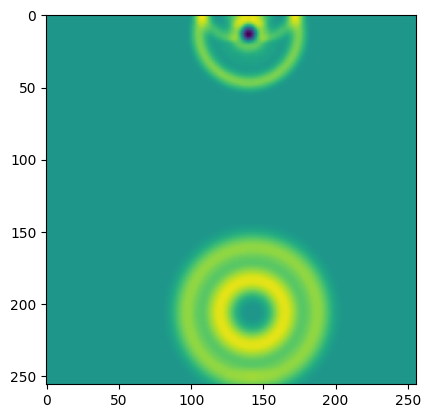

In [31]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

# Restore ordinary notebook plotting behaviour
plt.ion()
plt.close("all")

matplotlib.rcdefaults()

plt.imshow(trajectory_example['input_fields'][0, 5, :, :, 0, 0])
plt.show()

The `MixedWellDataset` object outputs several important fields:
- `input_fields` - These are time varying state variables to use as input. 
- `out_fields` - Time varying state variables that the model is expected to predict.
- `constant_fields` - Input values that don't vary with time. 
- `boundary_conditions` - list of lists containing the properties of the borders. These are restricted to topological details "periodic", "open", and "wall"/closed. For instance, the values [[0, 0], [1, 0], [2, 2]] would indicate the first axis (x) has closed boundaries on both sides, while the second (y) has an open boundary at ($y=0$) and closed at ($y=1$). The third (z) is periodic.
- `padded_field_mask` - When applying rotations, it can be difficult to tell which tensor-valued fields are real and which are from padding into higher dimensions. This lets us know which are which so we can evaluate only the true fields.
- `field_indices` - This is a new object in Walrus's `MixedWellDataset` that tracks mappings from field names to indices. This tells the model what types of fields it's using at any given time. 
- `metadata` - This is a typical Well metadata object, but as this type of object can sample from multiple data sources, this is passed to make it easier to track what type of data we're working with. 

```
# Boundary condition codes
class BoundaryCondition(Enum):
    WALL = 0
    OPEN = 1
    PERIODIC = 2
```

Now lets see how we can use the model to forecast the evolution of this field! Let's define a helper function which performs an autoregressive rollout. 

We want this helper to:
- Move our data to the target device
- Reshape the data into the format expected by Walrus
- Rollout the model as many steps as we have reference data for, performing appropriate normalization as we go

In [32]:
import copy
from walrus.trainer.training import expand_mask_to_match

def rollout_model(model, revin, batch, formatter, max_rollout_steps=200, model_epsilon=1e-5, device=torch.device("cpu")):
    """Rollout the model for as many steps as we have data for.

    Simplified version of the trainer method for demo purposes.
    """
    metadata = batch["metadata"]
    batch = {
        k: v.to(device)
        if k not in {"metadata", "boundary_conditions"}
        else v
        for k, v in batch.items()
    }
    # Extract mask and move to device for loss eval
    if (
        "mask" in batch["metadata"].constant_field_names[0] # Assuming all metadata in batch are the same
    ):
        mask_index = batch["metadata"].constant_field_names[0].index("mask")
        mask = batch["constant_fields"][..., mask_index : mask_index + 1]
        mask = mask.to(device, dtype=torch.bool)
    else:
        mask = None

    inputs, y_ref = formatter.process_input(
        batch,
        causal_in_time=model.causal_in_time,
        predict_delta=True,
        train=False,
    )

    # Inputs T B C H [W D], y_ref B T H [W D] C
    T_in = batch["input_fields"].shape[1]
    max_rollout_steps = max_rollout_steps + (T_in - 1)
    rollout_steps = min(y_ref.shape[1], max_rollout_steps)  # Number of timesteps in target
    train_rollout_limit = 1

    y_ref = y_ref[:, :rollout_steps] # If we set a maximum number of rollout steps, just cut it off now to save memory
    # Create a moving batch of one step at a time
    moving_batch = copy.deepcopy(batch)
    y_preds = []
    # Rollout the model - Causal in time gets more predictions from the first step
    for i in range(train_rollout_limit - 1, rollout_steps):
        # Don't fill causal_in_time here since that only affects y_ref
        inputs, _ = formatter.process_input(moving_batch)
        inputs = list(inputs)
        with torch.no_grad():
            normalization_stats = revin.compute_stats(
                inputs[0], metadata, epsilon=model_epsilon
            )
        # NOTE - Currently assuming only [0] (fields) needs normalization
        normalized_inputs = inputs[:]  # Shallow copy
        normalized_inputs[0] = revin.normalize_stdmean(
            normalized_inputs[0], normalization_stats
        )
        y_pred = model(
            normalized_inputs[0],
            normalized_inputs[1],
            normalized_inputs[2].tolist(),
            metadata=metadata,
        )
        # During validation, don't maintain full inner predictions
        if model.causal_in_time:
            y_pred = y_pred[-1:]  # y_pred is T first, y_ref is not
        # In validation, we want to reconstruct predictions on original scale
        y_pred = (inputs[0][-y_pred.shape[0]:].float() 
                  + revin.denormalize_delta(y_pred, normalization_stats))  # Unnormalize delta and add to input
        y_pred = formatter.process_output(y_pred, metadata)[..., : y_ref.shape[-1]]  # Cut off constant channels

        # If we have masked fields, just move them back to zeros
        if mask is not None:
            mask_pred = expand_mask_to_match(mask, y_pred)
            y_pred.masked_fill_(mask_pred, 0)

        y_pred = y_pred.masked_fill(~batch["padded_field_mask"], 0.0)

        # If not last step, update moving batch for autoregressive prediction
        if i != rollout_steps - 1:
            moving_batch["input_fields"] = torch.cat(
                [moving_batch["input_fields"][:, 1:], y_pred[:, -1:]], dim=1
            )
        # For causal models, we get use full predictions for the first batch and
        # incremental predictions for subsequent batches - concat 1:T to y_ref for loss eval
        if model.causal_in_time and i == train_rollout_limit - 1:
            y_preds.append(y_pred)
        else:
            y_preds.append(y_pred[:, -1:])
    y_pred_out = torch.cat(y_preds, dim=1)
    if mask is not None:
        mask_ref = expand_mask_to_match(mask, y_ref)
        y_ref.masked_fill_(mask_ref, 0)
    return y_pred_out, y_ref



Now lets make our forecast!

In [33]:
with torch.no_grad():
    trajectory_example["padded_field_mask"] = trajectory_example["padded_field_mask"].to(device) # We're going to want this out here too
    inputs, y_ref = formatter.process_input(
        trajectory_example,
        causal_in_time=model.causal_in_time,
        predict_delta=True,
        train=False,
    )
    y_pred, y_ref = rollout_model(
        model,
        revin,
        trajectory_example,
        formatter,
        max_rollout_steps=100,
        device=device,
    )

    # Lets get some extra info so we can visualize our data effectively
    # Remove unused fields
    y_pred, y_ref = (
        y_pred[..., trajectory_example["padded_field_mask"]],
        y_ref[..., trajectory_example["padded_field_mask"]],
    )
    # Collecting names to make detailed output logs
    field_names = flatten_field_names(metadata, include_constants=False)
    used_field_names = [
        f
        for i, f in enumerate(field_names)
        if trajectory_example["padded_field_mask"][i]
    ]

In [19]:
%pip install imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 193.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [34]:
import imageio_ffmpeg

ffmpeg_path = imageio_ffmpeg.get_ffmpeg_exe()
print(ffmpeg_path)

/mnt/home/pmukhopadhyay/projects/well_tutorial_test/well_venv_310/lib/python3.10/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2


In [35]:
import os
import sys
from pathlib import Path
import imageio_ffmpeg

source = Path(imageio_ffmpeg.get_ffmpeg_exe())
target = Path(sys.prefix) / "bin" / "ffmpeg"

if not target.exists():
    target.symlink_to(source)

print(target)


/mnt/home/pmukhopadhyay/projects/well_tutorial_test/well_venv_310/bin/ffmpeg


In [36]:
import shutil
import os
import sys

os.environ["PATH"] = f"{sys.prefix}/bin:" + os.environ["PATH"]

print(shutil.which("ffmpeg"))

/mnt/home/pmukhopadhyay/projects/well_tutorial_test/well_venv_310/bin/ffmpeg


In [37]:
from the_well.benchmark.metrics import make_video
output_dir = "./figures/"

make_video(
    y_pred[0],  # First sample only in batch
    y_ref[0],  # First sample only in batch
    metadata,
    output_dir=output_dir,
    epoch_number="ac_discontinuous_example",  # Misleading parameter name, but duck typing lets it be used for naming the output. Needs upstream fix.
    field_name_overrides=used_field_names,  # Fields actually used
    size_multiplier=1.,  # 
)

{}

In [38]:
from IPython.display import Video

Video(f'{output_dir}/{metadata.dataset_name}/rollout_video/epochac_discontinuous_example_{metadata.dataset_name}.mp4', width=640, height=360)




## How good is the rollout?

A video is useful, but it can hide systematic drift. We will now compare Walrus against a deliberately simple baseline:

> **Persistence baseline:** predict that the most recent input frame remains unchanged forever.

A foundation model should outperform this baseline over useful forecast horizons.


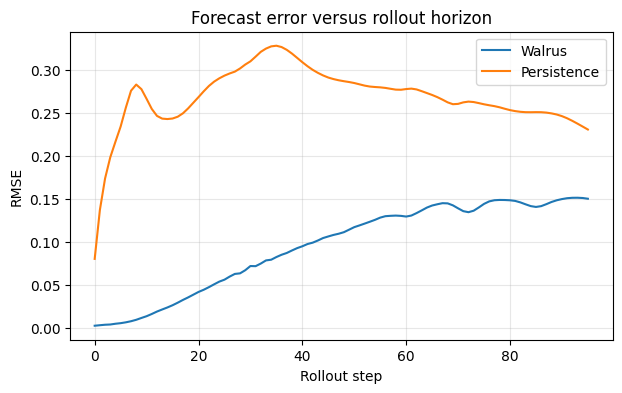

Walrus beats persistence on 100.0% of evaluated steps.


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# y_pred and y_ref have shape [B, T, spatial..., C]
pred = y_pred[0].float().cpu()
ref = y_ref[0].float().cpu()

# The final input frame is the persistence forecast for every future time.
last_input = trajectory_example["input_fields"][0, -1].float().cpu()
#print(last_input.shape)
last_input = last_input[..., trajectory_example["padded_field_mask"].cpu()]
#print(last_input.shape)
persistence = last_input.unsqueeze(0).expand_as(ref)
#print(persistence.shape)

reduce_dims = tuple(range(1, ref.ndim))
walrus_rmse = torch.sqrt(torch.mean((pred - ref) ** 2, dim=reduce_dims))
persistence_rmse = torch.sqrt(torch.mean((persistence - ref) ** 2, dim=reduce_dims))

plt.figure(figsize=(7, 4))
plt.plot(walrus_rmse.numpy(), label="Walrus")
plt.plot(persistence_rmse.numpy(), label="Persistence")
plt.xlabel("Rollout step")
plt.ylabel("RMSE")
plt.title("Forecast error versus rollout horizon")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

better_fraction = (walrus_rmse < persistence_rmse).float().mean().item()
print(f"Walrus beats persistence on {100 * better_fraction:.1f}% of evaluated steps.")

## Challenge: Beat the persistence baseline

The persistence baseline assumes that the system does not change:

\[
\hat{x}_{t+k} = x_t.
\]

Can you build a slightly stronger baseline using the last two input frames?

Assume that the most recently observed change continues at the same rate:

\[
\Delta x_t = x_t - x_{t-1},
\]

\[
\hat{x}_{t+k} = x_t + k\,\Delta x_t.
\]

### Your task

Using `trajectory_example["input_fields"]`:

1. Extract the last two context frames.
2. Compute the most recent change between them.
3. Generate a linear-extrapolation forecast with the same number of timesteps as the Walrus rollout.
4. Compare its predictions with:
   - the persistence baseline,
   - the Walrus rollout,
   - the ground truth.

### Think about

- Which baseline is best at very short forecast horizons?
- When does linear extrapolation begin to fail?
- Does it fail equally quickly for every physical field?
- Can the extrapolated solution produce physically unreasonable values?

In [40]:
# Challenge: implement a linear-extrapolation baseline

# Input fields have shape:
# [batch, context_time, spatial dimensions..., fields]
context = trajectory_example["input_fields"][0]

# TODO: extract the last two input frames
x_prev = ...
x_latest = ...

# TODO: estimate the most recent change
last_delta = ...

# Use the same number of forecast steps as the reference rollout
n_rollout_steps = y_ref.shape[1]

linear_predictions = []

for k in range(1, n_rollout_steps + 1):
    # TODO: linearly extrapolate k steps beyond the latest input
    x_pred = ...
    linear_predictions.append(x_pred)

# TODO: stack the predictions along the time dimension
linear_predictions = ...

# Add the batch dimension so that the shape matches y_ref
linear_predictions = ...

print("Reference shape:        ", y_ref.shape)
print("Linear baseline shape:  ", linear_predictions.shape)

Reference shape:         torch.Size([1, 96, 256, 256, 1, 3])


AttributeError: 'ellipsis' object has no attribute 'shape'

## Below is the solution to that. Please open it after trying the problem above.

Filtered context shape: torch.Size([6, 256, 256, 1, 3])
Walrus prediction shape: torch.Size([1, 96, 256, 256, 1, 3])
Reference shape: torch.Size([1, 96, 256, 256, 1, 3])
Linear prediction shape: torch.Size([1, 96, 256, 256, 1, 3])


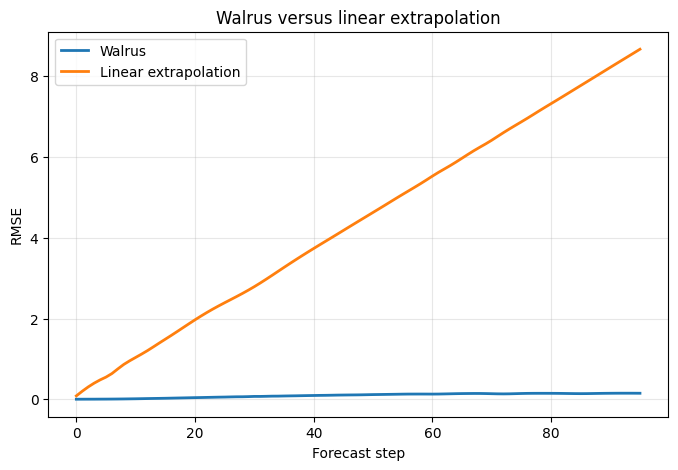

Mean Walrus RMSE:              0.094899
Mean linear-extrapolation RMSE: 4.399900
First forecast step where Walrus beats linear extrapolation: 0


In [41]:
# Solution: compare Walrus with linear extrapolation in time

import matplotlib.pyplot as plt
import torch

# 1. Extract the last two context frames

# Shape before filtering:
# [batch, context_time, H, W, D, padded_fields]
context = trajectory_example["input_fields"][0]

# Keep only the real physical fields, exactly as was done for y_pred/y_ref
field_mask = trajectory_example["padded_field_mask"].to(
    context.device, dtype=torch.bool
)
context = context[..., field_mask]

x_prev = context[-2]
x_latest = context[-1]

print("Filtered context shape:", context.shape)
print("Walrus prediction shape:", y_pred.shape)
print("Reference shape:", y_ref.shape)

# 2. Linear extrapolation baseline

last_delta = x_latest - x_prev
n_rollout_steps = y_ref.shape[1]

linear_predictions = []

for k in range(1, n_rollout_steps + 1):
    # Assume the most recently observed change remains constant
    x_pred_linear = x_latest + k * last_delta
    linear_predictions.append(x_pred_linear)

# [time, H, W, D, fields] -> [batch, time, H, W, D, fields]
linear_predictions = torch.stack(linear_predictions, dim=0).unsqueeze(0)

# Make sure all tensors are on the same device
linear_predictions = linear_predictions.to(y_ref.device)

print("Linear prediction shape:", linear_predictions.shape)

# 3. Compute RMSE at every forecast step

# Average over all spatial dimensions and fields, but not batch or time
reduce_dims = tuple(range(2, y_ref.ndim))

walrus_rmse = torch.sqrt(
    torch.mean((y_pred - y_ref) ** 2, dim=reduce_dims)
)[0]

linear_rmse = torch.sqrt(
    torch.mean((linear_predictions - y_ref) ** 2, dim=reduce_dims)
)[0]

# 4. Plot the comparison

plt.figure(figsize=(8, 5))

plt.plot(
    walrus_rmse.detach().cpu(),
    label="Walrus",
    linewidth=2,
)

plt.plot(
    linear_rmse.detach().cpu(),
    label="Linear extrapolation",
    linewidth=2,
)

plt.xlabel("Forecast step")
plt.ylabel("RMSE")
plt.title("Walrus versus linear extrapolation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Report which method performs better

walrus_mean_rmse = walrus_rmse.mean().item()
linear_mean_rmse = linear_rmse.mean().item()

print(f"Mean Walrus RMSE:              {walrus_mean_rmse:.6f}")
print(f"Mean linear-extrapolation RMSE: {linear_mean_rmse:.6f}")

better = torch.where(walrus_rmse < linear_rmse)[0]

if len(better) > 0:
    print(
        "First forecast step where Walrus beats linear extrapolation:",
        better[0].item(),
    )
else:
    print("Walrus does not beat linear extrapolation within this rollout.")



## Below we plot the linear extrapolation vs. walrus predictions

In [42]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

# Restore ordinary notebook plotting behaviour
plt.ion()
plt.close("all")

matplotlib.rcdefaults()

Truth: (256, 256) -0.98743284 3.231743
Walrus: (256, 256) -0.8958957 3.0525253
Linear: (256, 256) -40.535316 10.682035


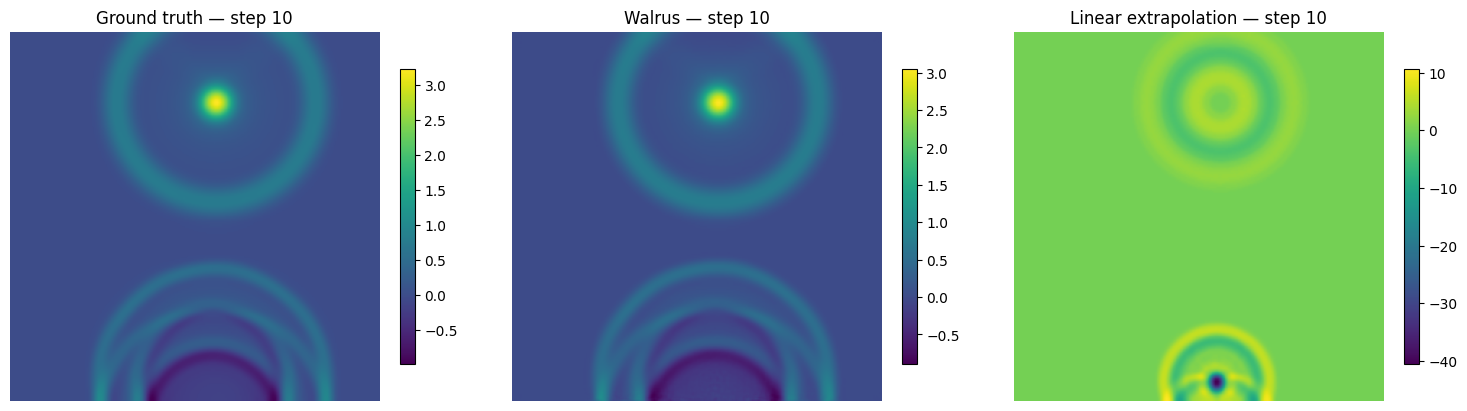

In [43]:
import matplotlib.pyplot as plt
from IPython.display import display

# Choose forecast step and field to visualise
step = 10
field_idx = 0

truth_frame  = y_ref[0, step, :, :, 0, field_idx].detach().cpu().numpy()
walrus_frame = y_pred[0, step, :, :, 0, field_idx].detach().cpu().numpy()
linear_frame = linear_predictions[0, step, :, :, 0, field_idx].detach().cpu().numpy()

print("Truth:", truth_frame.shape, truth_frame.min(), truth_frame.max())
print("Walrus:", walrus_frame.shape, walrus_frame.min(), walrus_frame.max())
print("Linear:", linear_frame.shape, linear_frame.min(), linear_frame.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

frames = [
    (truth_frame, "Ground truth"),
    (walrus_frame, "Walrus"),
    (linear_frame, "Linear extrapolation"),
]

for ax, (frame, title) in zip(axes, frames):
    im = ax.imshow(frame, origin="lower")
    ax.set_title(f"{title} — step {step}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8)


## Challenge 2: Can Walrus generalise to unseen context lengths?

The pretrained Walrus model was trained using a **fixed context length of 6 frames**.

What happens if we give it fewer frames at inference time?

Test context lengths

\[
T_{\mathrm{in}} \in \{1,2,3,4,5,6\}.
\]

For each context length:

1. Keep only the latest \(T_{\mathrm{in}}\) input frames.
2. Attempt to run the same Walrus rollout.
3. Record whether inference succeeds or fails.
4. For successful runs, compare the rollout RMSE against the standard 6-frame result.


### Questions

- Can Walrus accept context lengths that were never seen during training?
- If it runs, does performance degrade smoothly as context is removed?
- Is one frame enough to determine the future evolution?
- Where does any failure occur: preprocessing, positional encoding, model inference,
  or autoregressive rollout?
- How could training be modified to support variable context lengths?

In [43]:
# Challenge: test inference with unseen context lengths

import copy
import torch
import matplotlib.pyplot as plt

context_lengths = [1, 2, 3, 4, 5, 6]

context_results = {}
context_errors = {}

for context_length in context_lengths:

    # Make a fresh copy so that the original trajectory is not changed
    shortened_batch = copy.deepcopy(trajectory_example)

    # TODO 1:
    # Keep only the latest `context_length` input frames
    shortened_batch["input_fields"] = ...

    print(
        f"\nTrying context length {context_length}:",
        shortened_batch["input_fields"].shape,
    )

    try:
        with torch.no_grad():

            # TODO 2:
            # Run Walrus using the shortened context
            pred, ref = ...

            # TODO 3:
            # Keep only the real, unpadded physical fields
            field_mask = ...
            pred = ...
            ref = ...

            # Save successful predictions
            context_results[context_length] = {
                "prediction": pred,
                "reference": ref,
            }

            print("Success")

    except Exception as error:
        # A failure is also an important result
        context_errors[context_length] = str(error)
        print("Failed")
        print(type(error).__name__, error)


# TODO 4:
# For each successful context length, compute RMSE at every forecast step.

context_rmse = {}

for context_length, result in context_results.items():
    pred = result["prediction"]
    ref = result["reference"]

    reduce_dims = ...

    rmse = ...
    context_rmse[context_length] = rmse


# TODO 5:
# Plot RMSE versus forecast step for every successful context length.

fig, ax = plt.subplots(figsize=(8, 5))

for context_length, rmse in context_rmse.items():
    ...

ax.set_xlabel("Forecast step")
ax.set_ylabel("RMSE")
ax.set_title("Walrus performance with different context lengths")
ax.legend()
ax.grid(alpha=0.3)

plt.show()



AttributeError: 'ellipsis' object has no attribute 'shape'

## Solution below... please only see after you have tried out the problem


Trying context length 1: (1, 1, 256, 256, 1, 4)
Success
Prediction shape: (1, 50, 256, 256, 1, 3)
Reference shape:  (1, 50, 256, 256, 1, 3)

Trying context length 2: (1, 2, 256, 256, 1, 4)
Success
Prediction shape: (1, 51, 256, 256, 1, 3)
Reference shape:  (1, 51, 256, 256, 1, 3)

Trying context length 3: (1, 3, 256, 256, 1, 4)
Success
Prediction shape: (1, 52, 256, 256, 1, 3)
Reference shape:  (1, 52, 256, 256, 1, 3)

Trying context length 4: (1, 4, 256, 256, 1, 4)
Success
Prediction shape: (1, 53, 256, 256, 1, 3)
Reference shape:  (1, 53, 256, 256, 1, 3)

Trying context length 5: (1, 5, 256, 256, 1, 4)
Success
Prediction shape: (1, 54, 256, 256, 1, 3)
Reference shape:  (1, 54, 256, 256, 1, 3)

Trying context length 6: (1, 6, 256, 256, 1, 4)
Success
Prediction shape: (1, 55, 256, 256, 1, 3)
Reference shape:  (1, 55, 256, 256, 1, 3)

SUMMARY
Context 1: success
Context 2: success
Context 3: success
Context 4: success
Context 5: success
Context 6: success

Common comparison horizon: 50


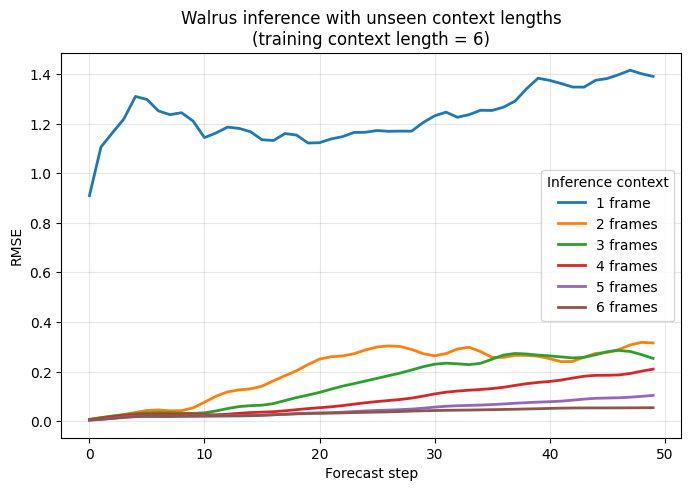


Mean RMSE over the common forecast horizon
Context 1: 1.232649
Context 2: 0.202137
Context 3: 0.155741
Context 4: 0.090663
Context 5: 0.048910
Context 6: 0.035674


In [50]:
# Solution: test Walrus with unseen context lengths

import copy
import torch
import matplotlib.pyplot as plt

context_lengths = [1, 2, 3, 4, 5, 6]

context_results = {}
context_errors = {}

# 50 step rollout 
max_rollout_steps = 50

for context_length in context_lengths:

    # Start from a fresh copy for every context length
    shortened_batch = copy.deepcopy(trajectory_example)

    # Keep only the latest context frames
    shortened_batch["input_fields"] = shortened_batch[
        "input_fields"
    ][:, -context_length:]

    print(
        f"\nTrying context length {context_length}:",
        tuple(shortened_batch["input_fields"].shape),
    )

    try:
        with torch.no_grad():
            pred, ref = rollout_model(
                model,
                revin,
                shortened_batch,
                formatter,
                max_rollout_steps=max_rollout_steps,
                device=device,
            )

        field_mask = shortened_batch["padded_field_mask"].to(
            pred.device,
            dtype=torch.bool,
        )

        pred = pred[..., field_mask]
        ref = ref[..., field_mask]

        context_results[context_length] = {
            "prediction": pred.detach().cpu(),
            "reference": ref.detach().cpu(),
        }

        print("Success")
        print("Prediction shape:", tuple(pred.shape))
        print("Reference shape: ", tuple(ref.shape))

    except Exception as error:
        context_errors[context_length] = {
            "type": type(error).__name__,
            "message": str(error),
        }

        print("Failed")
        print(f"{type(error).__name__}: {error}")


# Did all context lengths work?#

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

for context_length in context_lengths:
    if context_length in context_results:
        print(f"Context {context_length}: success")
    else:
        error = context_errors[context_length]
        print(
            f"Context {context_length}: failed "
            f"({error['type']})"
        )


# Use a common forecast horizon for a fair comparison

if context_results:
    common_horizon = min(
        result["prediction"].shape[1]
        for result in context_results.values()
    )

    print("\nCommon comparison horizon:", common_horizon)

    context_rmse = {}

    for context_length, result in context_results.items():
        pred = result["prediction"][:, :common_horizon]
        ref = result["reference"][:, :common_horizon]

        # Average over spatial dimensions and fields, retaining batch and time
        reduce_dims = tuple(range(2, pred.ndim))

        rmse = torch.sqrt(
            torch.mean(
                (pred - ref) ** 2,
                dim=reduce_dims,
            )
        )

        # Average over the batch dimension
        context_rmse[context_length] = rmse.mean(dim=0)


    
    # Plot RMSE against forecast step
    

    fig, ax = plt.subplots(figsize=(8, 5))

    for context_length in sorted(context_rmse):
        ax.plot(
            context_rmse[context_length].numpy(),
            label=f"{context_length} frame"
            + ("s" if context_length != 1 else ""),
            linewidth=2,
        )

    ax.set_xlabel("Forecast step")
    ax.set_ylabel("RMSE")
    ax.set_title(
        "Walrus inference with unseen context lengths\n"
        "(training context length = 6)"
    )
    ax.legend(title="Inference context")
    ax.grid(alpha=0.3)

    plt.show()


    
    # Print mean error over the common rollout
    

    print("\nMean RMSE over the common forecast horizon")

    for context_length in sorted(context_rmse):
        mean_rmse = context_rmse[context_length].mean().item()
        print(
            f"Context {context_length}: "
            f"{mean_rmse:.6f}"
        )

else:
    print(
        "\nNo context length completed successfully. "
        "This indicates that the model or preprocessing pipeline requires "
        "the six-frame training interface."
    )

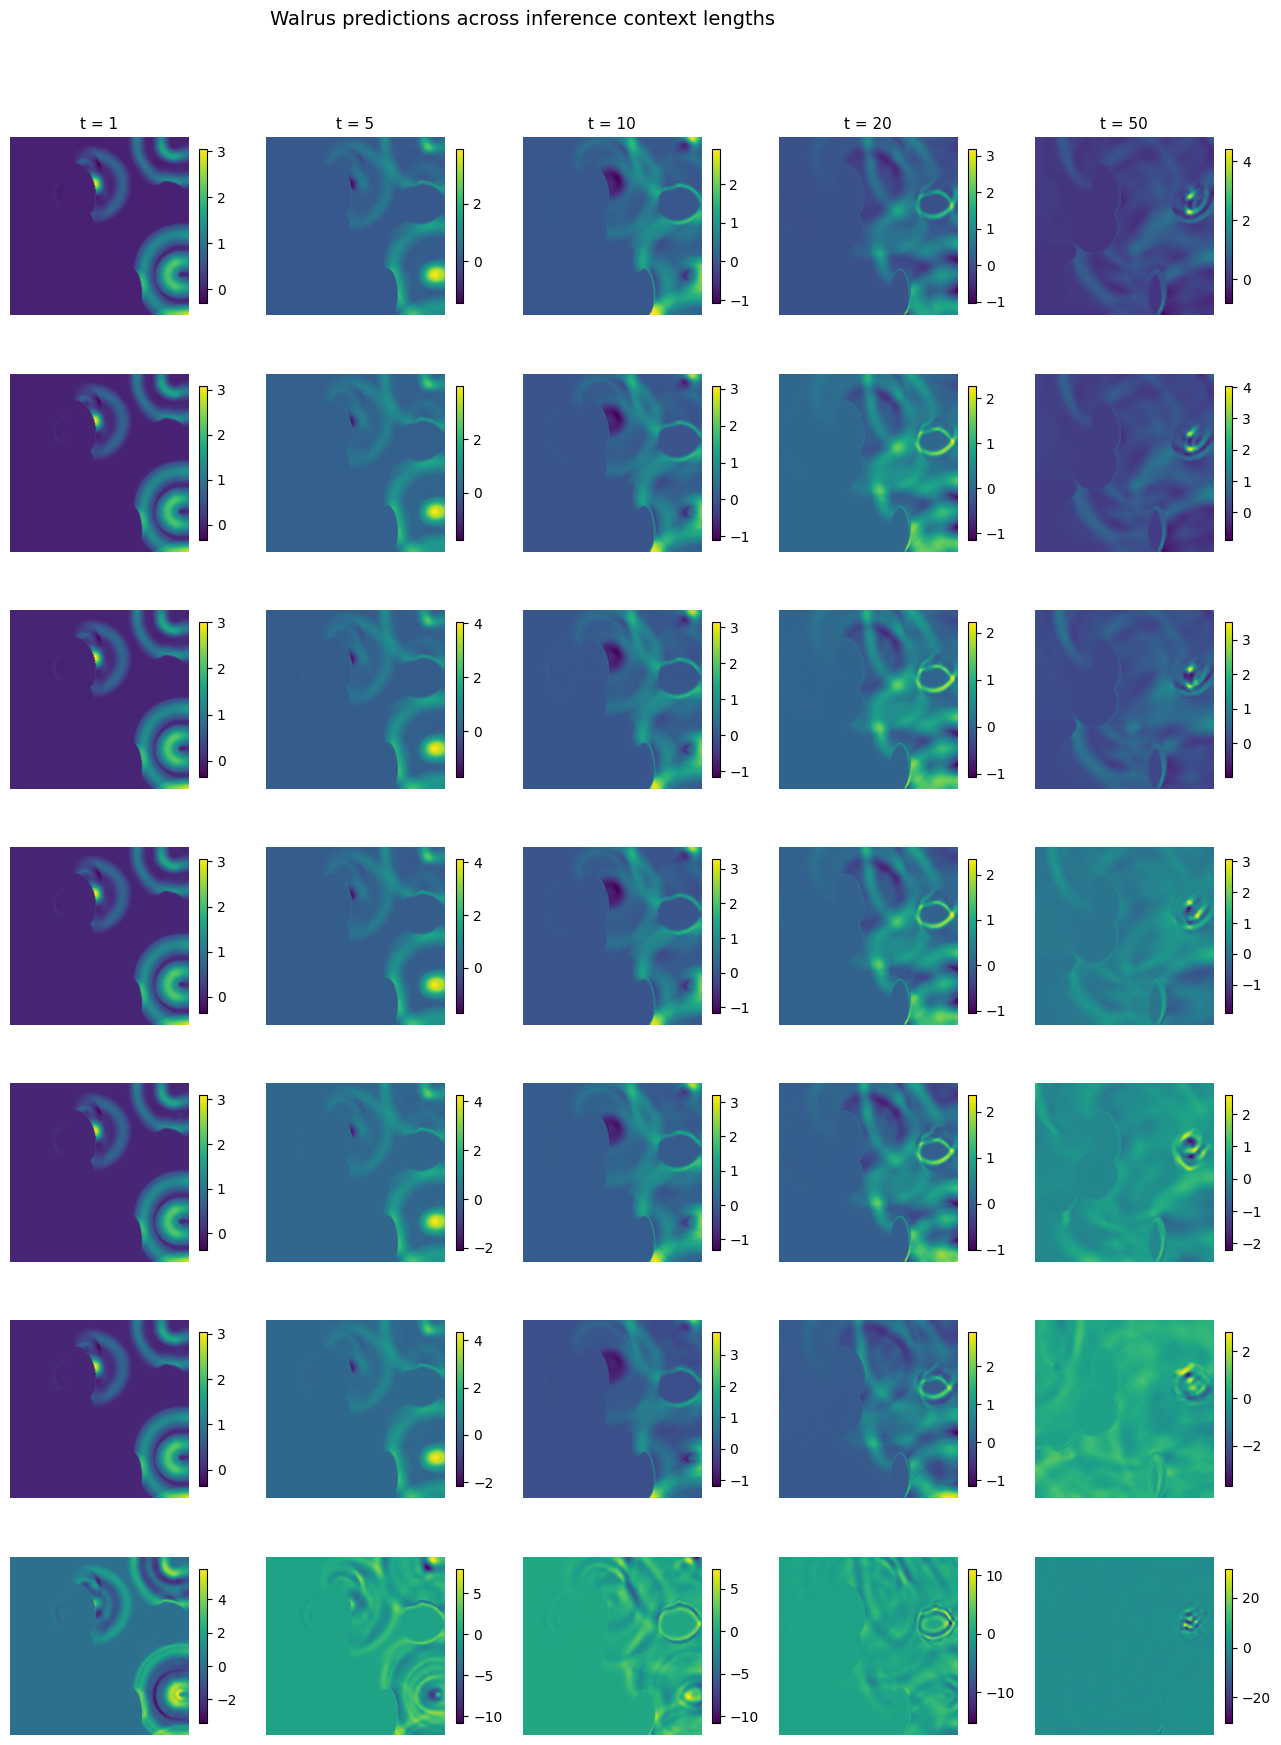

In [49]:
import matplotlib.pyplot as plt

time_steps = [1, 5, 10, 20, 50]
field_idx = 0

successful_contexts = sorted(context_results.keys(), reverse=True)

if not successful_contexts:
    print("No successful context-length runs to plot.")

else:
    max_common_time = min(
        result["prediction"].shape[1]
        for result in context_results.values()
    )

    time_steps = [t for t in time_steps if t <= max_common_time]

    if 6 in successful_contexts:
        context_order = [6] + [c for c in successful_contexts if c != 6]
    else:
        context_order = successful_contexts

    reference_context = 6 if 6 in context_results else context_order[0]
    reference = context_results[reference_context]["reference"]

    row_labels = ["Ground truth"] + [f"Context = {c}" for c in context_order]

    n_rows = len(row_labels)
    n_cols = len(time_steps)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.2 * n_cols, 2.7 * n_rows),
        squeeze=False,
    )

    fig.subplots_adjust(left=0.18, right=0.96, top=0.92, bottom=0.06, wspace=0.15, hspace=0.15)

    for col, t in enumerate(time_steps):
        frame = reference[0, t - 1, :, :, 0, field_idx].numpy()

        im = axes[0, col].imshow(frame, origin="lower")
        axes[0, col].set_title(f"t = {t}", fontsize=11)
        axes[0, col].axis("off")
        fig.colorbar(im, ax=axes[0, col], shrink=0.75)

    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(
            label,
            fontsize=12,
            rotation=0,
            labelpad=55,
            va="center",
        )

    for row, context_length in enumerate(context_order, start=1):
        prediction = context_results[context_length]["prediction"]

        for col, t in enumerate(time_steps):
            frame = prediction[0, t - 1, :, :, 0, field_idx].numpy()

            im = axes[row, col].imshow(frame, origin="lower")
            axes[row, col].axis("off")
            fig.colorbar(im, ax=axes[row, col], shrink=0.75)

    fig.suptitle(
        "Walrus predictions across inference context lengths",
        fontsize=14,
    )

    plt.show()

## Challenge 3: Does Walrus generalise across temporal strides?

During pretraining, Walrus was shown temporal strides sampled uniformly from

[
s \in {1,2,3,4,5}.
]

A temporal stride of (s) means that consecutive context frames are separated by (s) simulation steps.

For example, with six context frames:

* stride 1 uses frames `[0, 1, 2, 3, 4, 5]`
* stride 2 uses frames `[0, 2, 4, 6, 8, 10]`
* stride 5 uses frames `[0, 5, 10, 15, 20, 25]`

Test Walrus using both:

* strides seen during pretraining: `1, 2, 3, 4, 5`
* unseen strides: `6, 8, 10`

For each stride:

1. Construct six context frames with the chosen temporal spacing.
2. Keep the first prediction time fixed across all strides.
3. Run Walrus autoregressively.
4. Compare the predictions with the corresponding ground truth.
5. Plot the rollout error against physical forecast time.

### Questions

* Does performance change smoothly across strides 1–5?
* Which stride performs best?
* What happens beyond the largest training stride?
* Does the model fail abruptly or degrade gradually?
* Is a larger stride harder because the system changes more between context frames?


In [36]:
import copy

import torch
from hydra.utils import instantiate
from omegaconf import OmegaConf, open_dict

dataset_name = "acoustic_scattering_inclusions"
strides = [1, 2, 3, 4, 5, 6, 8, 10]
first_output_index = 60

stride_results = {}
stride_errors = {}

for stride in strides:
    try:
        # TODO:
        # Create a copy of the configuration for this stride.
        #
        # Configure the data module so that:
        # - only `dataset_name` is loaded;
        # - the temporal stride is fixed to `stride`;
        # - the first prediction begins at `first_output_index`.

        stride_config = ...

        # TODO:
        # Instantiate the data module and load one rollout-validation batch.

        stride_data_module = ...
        stride_batch = ...

        # TODO:
        # Work out the six context-frame indices.
        #
        # Hint: the first prediction time must be identical for every stride.

        input_indices = ...

        # TODO:
        # Convert the batch time grids to times on the original simulation
        # timeline.
        #
        # The spacing between consecutive stored simulation frames is:
        dt = 2.0 / 101

        global_input_times = ...
        global_output_times = ...

        print(f"\nStride {stride}")
        print("Input indices:", input_indices)
        print("First output index:", first_output_index)
        print("Input shape:", tuple(stride_batch["input_fields"].shape))
        print("Output shape:", tuple(stride_batch["output_fields"].shape))
        print("Global input times:", global_input_times)
        print("Global output times:", global_output_times)

        # TODO:
        # Run an autoregressive rollout for up to 100 steps.

        prediction, reference = ...

        # TODO:
        # Remove padded fields before computing errors.

        prediction = ...
        reference = ...

        # TODO:
        # Compute the rollout RMSE at each output time.

        rollout_rmse = ...

        stride_results[stride] = {
            "prediction": prediction.detach().cpu(),
            "reference": reference.detach().cpu(),
            "output_time_grid": global_output_times.detach().cpu(),
            "rollout_rmse": rollout_rmse.detach().cpu(),
        }

    except Exception as error:
        stride_errors[stride] = str(error)
        print(f"Stride {stride} failed: {error}")


Stride 1
Input indices: Ellipsis
First output index: 60
Stride 1 failed: 'ellipsis' object is not subscriptable

Stride 2
Input indices: Ellipsis
First output index: 60
Stride 2 failed: 'ellipsis' object is not subscriptable

Stride 3
Input indices: Ellipsis
First output index: 60
Stride 3 failed: 'ellipsis' object is not subscriptable

Stride 4
Input indices: Ellipsis
First output index: 60
Stride 4 failed: 'ellipsis' object is not subscriptable

Stride 5
Input indices: Ellipsis
First output index: 60
Stride 5 failed: 'ellipsis' object is not subscriptable

Stride 6
Input indices: Ellipsis
First output index: 60
Stride 6 failed: 'ellipsis' object is not subscriptable

Stride 8
Input indices: Ellipsis
First output index: 60
Stride 8 failed: 'ellipsis' object is not subscriptable

Stride 10
Input indices: Ellipsis
First output index: 60
Stride 10 failed: 'ellipsis' object is not subscriptable


### Hints

- The six input indices should form an arithmetic sequence with spacing `stride`.
- The final context frame must occur immediately before the first predicted frame.
- The time grids returned by the batch are relative to the beginning of the sampled sequence.
- `padded_field_mask` identifies the real physical fields.
- Compute RMSE over all spatial dimensions and physical fields, while retaining the rollout-time dimension.

## Solution cells below.. please look at it after having tried the challenge before

In [60]:
import copy

import torch
from hydra.utils import instantiate
from omegaconf import OmegaConf, open_dict

dataset_name = "acoustic_scattering_inclusions"
strides = [1, 2, 3, 4, 5, 6, 8, 10]
first_output_index = 60

stride_results = {}
stride_errors = {}

for stride in strides:
    stride_config = copy.deepcopy(config)

    dataset_settings = copy.deepcopy(
        stride_config.data.module_parameters.well_dataset_info[
            dataset_name
        ]
    )

    with open_dict(stride_config):
        stride_config.data.module_parameters.min_dt_stride = stride
        stride_config.data.module_parameters.max_dt_stride = stride

        stride_config.data.module_parameters.start_rollout_valid_output_at_t = (
            first_output_index
        )

        stride_config.data.module_parameters.well_dataset_info = (
            OmegaConf.create(
                {
                    dataset_name: dataset_settings,
                }
            )
        )

    try:
        stride_data_module = instantiate(
            stride_config.data.module_parameters,
            well_base_path=well_base_path,
            world_size=1,
            rank=0,
            data_workers=1,
            field_index_map_override=stride_config.data.get(
                "field_index_map_override",
                {},
            ),
            prefetch_field_names=False,
        )

        stride_batch = next(
            iter(stride_data_module.rollout_val_dataloaders()[0])
        )

        first_input_index = first_output_index - 6 * stride

        dt = 2.0 / 101

        global_input_times = (
            stride_batch["input_time_grid"]
            + first_input_index * dt
        )

        global_output_times = (
            stride_batch["output_time_grid"]
            + first_input_index * dt
        )

        print(f"\nStride {stride}")
        print(
            "Input indices:",
            list(
                range(
                    first_input_index,
                    first_output_index,
                    stride,
                )
            ),
        )
        print("First output index:", first_output_index)
        print("Input shape:", tuple(stride_batch["input_fields"].shape))
        print("Output shape:", tuple(stride_batch["output_fields"].shape))
        print("Global input times:", global_input_times)
        print("Global output times:", global_output_times)

        with torch.no_grad():
            prediction, reference = rollout_model(
                model,
                revin,
                stride_batch,
                formatter,
                max_rollout_steps=100,
                device=device,
            )

        field_mask = stride_batch["padded_field_mask"].to(
            prediction.device,
            dtype=torch.bool,
        )

        prediction = prediction[..., field_mask]
        reference = reference[..., field_mask]

        stride_results[stride] = {
            "prediction": prediction.detach().cpu(),
            "reference": reference.detach().cpu(),
            "input_time_grid": global_input_times.detach().cpu(),
            "output_time_grid": global_output_times.detach().cpu(),
            "first_output_index": first_output_index,
        }

        print("Success")

    except Exception as error:
        stride_errors[stride] = str(error)

        print(f"\nStride {stride} failed")
        print(type(error).__name__, error)


Stride 1
Input indices: [54, 55, 56, 57, 58, 59]
First output index: 60
Input shape: (1, 6, 256, 256, 1, 4)
Output shape: (1, 42, 256, 256, 1, 4)
Global input times: tensor([[1.0693, 1.0891, 1.1089, 1.1287, 1.1485, 1.1683]])
Global output times: tensor([[1.1881, 1.2079, 1.2277, 1.2475, 1.2673, 1.2871, 1.3069, 1.3267, 1.3465,
         1.3663, 1.3861, 1.4059, 1.4257, 1.4455, 1.4653, 1.4851, 1.5050, 1.5248,
         1.5446, 1.5644, 1.5842, 1.6040, 1.6238, 1.6436, 1.6634, 1.6832, 1.7030,
         1.7228, 1.7426, 1.7624, 1.7822, 1.8020, 1.8218, 1.8416, 1.8614, 1.8812,
         1.9010, 1.9208, 1.9406, 1.9604, 1.9802, 2.0000]])
Success

Stride 2
Input indices: [48, 50, 52, 54, 56, 58]
First output index: 60
Input shape: (1, 6, 256, 256, 1, 4)
Output shape: (1, 21, 256, 256, 1, 4)
Global input times: tensor([[0.9505, 0.9901, 1.0297, 1.0693, 1.1089, 1.1485]])
Global output times: tensor([[1.1881, 1.2277, 1.2673, 1.3069, 1.3465, 1.3861, 1.4257, 1.4653, 1.5050,
         1.5446, 1.5842, 1.6238, 1

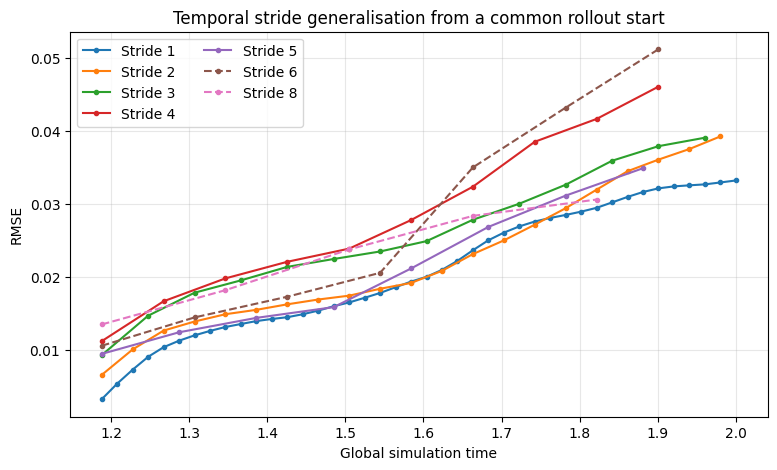

In [62]:
import matplotlib.pyplot as plt
import torch

fig, ax = plt.subplots(figsize=(9, 5))

for stride in sorted(stride_results):
    prediction = stride_results[stride]["prediction"]
    reference = stride_results[stride]["reference"]

    n_steps = min(prediction.shape[1], reference.shape[1])

    prediction = prediction[:, :n_steps]
    reference = reference[:, :n_steps]

    rmse = torch.sqrt(
        torch.mean(
            (prediction - reference) ** 2,
            dim=tuple(range(2, prediction.ndim)),
        )
    ).mean(dim=0)

    times = (
        stride_results[stride]["output_time_grid"]
        .reshape(-1)[:n_steps]
        .numpy()
    )

    linestyle = "-" if stride <= 5 else "--"

    ax.plot(
        times,
        rmse.numpy(),
        marker="o",
        markersize=3,
        linestyle=linestyle,
        label=f"Stride {stride}",
    )

ax.set_xlabel("Global simulation time")
ax.set_ylabel("RMSE")
ax.set_title("Temporal stride generalisation from a common rollout start")
ax.legend(ncol=2)
ax.grid(alpha=0.3)

plt.show()

Target frame: 96
Target time: 1.900990099009901
Available strides: [1, 2, 3, 4, 6]


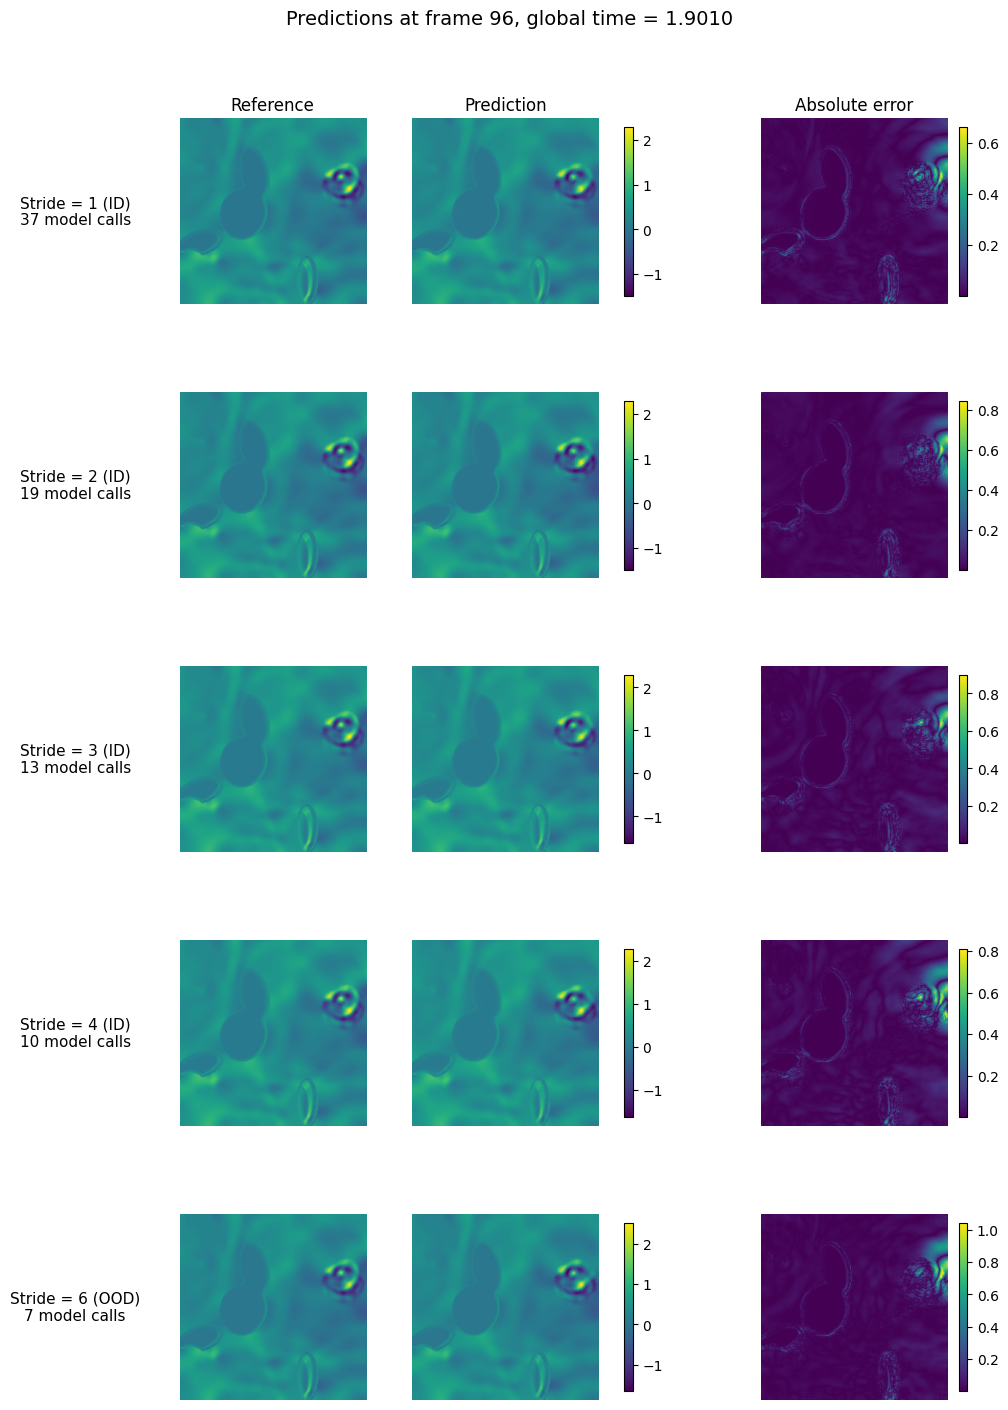

In [63]:
import matplotlib.pyplot as plt
import numpy as np

field_idx = 0
target_frame = 96
target_time = target_frame * 2.0 / 101

strides_to_plot = [1, 2, 3, 4, 6]

available_strides = []

for stride in strides_to_plot:
    times = (
        stride_results[stride]["output_time_grid"]
        .reshape(-1)
        .numpy()
    )

    if np.any(np.isclose(times, target_time, atol=1e-4)):
        available_strides.append(stride)

print("Target frame:", target_frame)
print("Target time:", target_time)
print("Available strides:", available_strides)

fig, axes = plt.subplots(
    len(available_strides),
    3,
    figsize=(11, 3 * len(available_strides)),
    squeeze=False,
)

fig.subplots_adjust(
    left=0.20,
    right=0.94,
    top=0.92,
    bottom=0.04,
    wspace=0.25,
    hspace=0.22,
)

axes[0, 0].set_title("Reference")
axes[0, 1].set_title("Prediction")
axes[0, 2].set_title("Absolute error")

for row, stride in enumerate(available_strides):
    prediction = stride_results[stride]["prediction"]
    reference = stride_results[stride]["reference"]

    times = (
        stride_results[stride]["output_time_grid"]
        .reshape(-1)
        .numpy()
    )

    step = np.where(
        np.isclose(times, target_time, atol=1e-4)
    )[0][0]

    ref_frame = reference[
        0, step, :, :, 0, field_idx
    ].numpy()

    pred_frame = prediction[
        0, step, :, :, 0, field_idx
    ].numpy()

    error_frame = np.abs(pred_frame - ref_frame)

    vmin = min(ref_frame.min(), pred_frame.min())
    vmax = max(ref_frame.max(), pred_frame.max())

    field_image = axes[row, 0].imshow(
        ref_frame,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    axes[row, 1].imshow(
        pred_frame,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    error_image = axes[row, 2].imshow(
        error_frame,
        origin="lower",
    )

    for col in range(3):
        axes[row, col].axis("off")

    model_calls = step + 1
    status = "ID" if stride <= 5 else "OOD"

    row_position = axes[row, 0].get_position()

    fig.text(
        0.105,
        (row_position.y0 + row_position.y1) / 2,
        f"Stride = {stride} ({status})\n"
        f"{model_calls} model calls",
        ha="center",
        va="center",
        fontsize=11,
    )

    fig.colorbar(
        field_image,
        ax=axes[row, :2],
        shrink=0.75,
    )

    fig.colorbar(
        error_image,
        ax=axes[row, 2],
        shrink=0.75,
    )

fig.suptitle(
    f"Predictions at frame {target_frame}, "
    f"global time = {target_time:.4f}",
    fontsize=14,
)

plt.show()

Awesome! We've made predictions with our pretrained model. Now let's look into what would happen if we needed to use the model for a downstream task and didn't want to go through the effort of first moving the data into the Well format.

## Part 2: Non-Well data

Now lets see what we'd do in the case where we don't have Well structured data. The key difference here is that we'd need to define our own data transformation objects to make sure that every object in the pipeline is getting the data in the format they need it.

We also need to make sure that our field_to_index_map is lined up with the new data which may include fields we haven't seen before.

First let's get some extra imports from the library out of the way.

In [11]:
from walrus.utils.experiment_utils import align_checkpoint_with_field_to_index_map
from the_well.data.datasets import WellMetadata

Let's make a hypothetical dataset. This dataset has 4 fields - velocity_x, velocity_y, density, and a new, never-before-seen field "blubber". First, we'll check out the existing `field_to_index_map` to see what we can use:

In [12]:
field_to_index_map

{'closed_boundary': 0, 'open_boundary': 1, 'bias_correction': 2, 'pressure': 3, 'velocity_x': 4, 'velocity_y': 5, 'velocity_z': 6, 'zeros_like_density': 7, 'speed_of_sound': 8, 'concentration': 9, 'D_xx': 10, 'D_xy': 11, 'D_xz': 12, 'D_yx': 13, 'D_yy': 14, 'D_yz': 15, 'D_zx': 16, 'D_zy': 17, 'D_zz': 18, 'E_xx': 19, 'E_xy': 20, 'E_xz': 21, 'E_yx': 22, 'E_yy': 23, 'E_yz': 24, 'E_zx': 25, 'E_zy': 26, 'E_zz': 27, 'density': 28, 'energy': 29, 'velocity_r': 30, 'velocity_theta': 31, 'velocity_phi': 32, 'momentum_x': 33, 'momentum_y': 34, 'momentum_z': 35, 'pressure_re': 36, 'pressure_im': 37, 'mask': 38, 'magnetic_field_x': 39, 'magnetic_field_y': 40, 'magnetic_field_z': 41, 'A': 42, 'B': 43, 'height': 44, 'internal_energy': 45, 'temperature': 46, 'electron_fraction': 47, 'entropy': 48, 'magnetic_field_log_r': 49, 'magnetic_field_theta': 50, 'magnetic_field_phi': 51, 'velocity_log_r': 52, 'buoyancy': 53, 'tracer': 54, 'log10_density': 55, 'log10_temperature': 56, 'c_zz': 57, 'C_xx': 58, 'C_x

Three of our fields are covered. Additionally, since Walrus is expecting dimensionally padded data, we'll also need to include a velocity_x which we can concatenate to the end since these are treated as sets and the order doesn't matter.

So we'll be passing fields {"velocity_x": 4, "velocity_y":5, "velocity_z": 6, "density": 28, "blubber": ?????} in the order [4, 5, 28, ????. 6]. 

The question we need to answer is: how do we deal with blubber? This is fortunately easy enough, we just need to add an extra field to this mapping dictionary and pass it appropriately.

In [13]:
new_field_to_index_map = copy.deepcopy(field_to_index_map)
new_field_to_index_map["blubber"] = max(field_to_index_map.values()) + 1  # New index for "blubber"

model = instantiate(
    config.model,
    n_states=max(new_field_to_index_map.values()) + 1,
)


# Use the Walrus utility to align the checkpoint
revised_model_checkpoint = align_checkpoint_with_field_to_index_map(
    checkpoint_state_dict=checkpoint,
    model_state_dict=model.state_dict(),
    checkpoint_field_to_index_map=field_to_index_map,
    model_field_to_index_map=new_field_to_index_map,
)

# Now load the aligned weights
model.load_state_dict(revised_model_checkpoint)

model.to(device)
model.eval()

/mnt/home/mmccabe/venvs/clean_walrus/lib/python3.11/site-packages/walrus/models/temporal_blocks/axial_time_attention.py:38: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  init.kaiming_uniform(


IsotropicModel(
  (patch_jitterer): FixedPatchJittererBoundaryPad()
  (embed): ModuleDict(
    (2): SpaceBagAdaptiveDVstrideEncoder(
      (proj1): Conv3d(68, 352, kernel_size=(8, 8, 8), stride=(1, 1, 1), bias=False)
      (norm1): RMSGroupNorm(16, 352, eps=1e-06, affine=True)
      (act): SiLU()
      (proj2): Conv3d(352, 1408, kernel_size=(4, 4, 4), stride=(1, 1, 1), bias=False)
      (norm2): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
    )
    (3): SpaceBagAdaptiveDVstrideEncoder(
      (proj1): Conv3d(68, 352, kernel_size=(8, 8, 8), stride=(1, 1, 1), bias=False)
      (norm1): RMSGroupNorm(16, 352, eps=1e-06, affine=True)
      (act): SiLU()
      (proj2): Conv3d(352, 1408, kernel_size=(4, 4, 4), stride=(1, 1, 1), bias=False)
      (norm2): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
    )
  )
  (blocks): ModuleList(
    (0): SpaceTimeSplitBlock(
      (space_mixing): FullAttention(
        (norm1): RMSGroupNorm(16, 1408, eps=1e-06, affine=True)
        (fused_ff_qkv): Line

Now we just need to pass data with the right signature. From before, we know the model is using the following fields:
- `input_fields` - float tensor [B x T_in x H x W x D x C_var]
- `output_fields` - float tensor [B x T_out x H x W x D x C_var]
- `constant_fields` - Optional, float tensor[B x H x W x D x C_con]
- `boundary_conditions` - int tensor [Bx3x2] 
- `padded_field_mask` - bool tensor [C_var] 
- `field_indices` - Int tensor [C_var + C_con] 
- `metadata` - WellMetadata - Not strictly necessary, but our functions above use this to help with logging, so we'll make one here too

In [14]:
B = 1
T_in = 6
T_out = 10
H = 128
W = 128
D = 1
C_var = 5  # velocity_x, velocity_y, velocity_z, density, blubber
C_con = 0  # No constant fields in this example


synthetic_trajectory_example = {
    "input_fields": torch.randn(B, T_in, H, W, D, C_var, device=device),
    "output_fields": torch.randn(B, T_out, H, W, D, C_var, device=device),
    "constant_fields": torch.randn(B, H, W, D, C_con, device=device),
    "boundary_conditions": torch.tensor([[[2, 2], [2, 2], [2, 2]] for _ in range(B)], device=device),  # Example BCs
    "padded_field_mask": torch.tensor([True, True, True, True, False], device=device),  # Last field index is padded
    "field_indices": torch.tensor([4, 5, 28, 67, 6], device=device),  # Indices for all fields
    "metadata": WellMetadata(
        dataset_name="synthetic_dataset",
        n_spatial_dims=3,
        field_names={0: ['pressure', "blubber"], 1: ['velocity_x', 'velocity_y', 'velocity_z'], 2: []},
        spatial_resolution=(128, 128, 1),
        scalar_names=[], 
        constant_field_names={0: [], 1: [], 2: []},
        constant_scalar_names=[],
        boundary_condition_types=[], # Doesn't matter
        n_files =[], # Doesn't matter
        n_trajectories_per_file=[], # Doesn't matter
        n_steps_per_trajectory=[], # Doesn't matter
    ),
}


In [15]:
with torch.no_grad():
    synthetic_trajectory_example["padded_field_mask"] = synthetic_trajectory_example["padded_field_mask"].to(device) # We're going to want this out here too
    inputs, y_ref = formatter.process_input(
        synthetic_trajectory_example,
        causal_in_time=model.causal_in_time,
        predict_delta=True,
        train=False,
    )
    fake_metadata = synthetic_trajectory_example["metadata"]
    y_pred, y_ref = rollout_model(
        model,
        revin,
        synthetic_trajectory_example,
        formatter,
        max_rollout_steps=200,
        device=device,
    )

    # Lets get some extra info so we can visualize our data effectively
    # Remove unused fields
    y_pred, y_ref = (
        y_pred[..., synthetic_trajectory_example["padded_field_mask"]],
        y_ref[..., synthetic_trajectory_example["padded_field_mask"]],
    )
    # Collecting names to make detailed output logs
    field_names = flatten_field_names(fake_metadata, include_constants=False)
    used_field_names = [
        f
        for i, f in enumerate(field_names)
        if synthetic_trajectory_example["padded_field_mask"][i]
    ]

In [4]:
ls /mnt/home/polymathic/ceph/the_well/datasets/acoustic_scattering_discontinuous/data/test/

acoustic_scattering_discontinuous_chunk_18.hdf5
acoustic_scattering_discontinuous_chunk_19.hdf5


Congratulations! Now you've used Walrus with both data in the Well format and independent data. Generally when using our training code, it's going to be much easier to use Well formatted data as it handles most of what we've just done automatically for Well formatted data. If you need some guidance on how to do that, we have an example in a second notebook. 